In [1]:
import tensorflow as tf
import numpy as np
import random
import matplotlib.pyplot as plt
import tqdm
np.set_printoptions(precision=4)



In [43]:
# Parameters for the simulation
num_baskets = 100000
basket_size = 3
embedding_dim = 5
n_items = 8
K_noise = 2
batch_size = 10
Q_distribution = tf.constant([1.0 / (n_items - 1)] * n_items, dtype=tf.float32)
assortment = tf.constant([i for i in range(n_items)])  # All items are available
Wi = tf.Variable(tf.random.normal((embedding_dim, n_items), stddev=0.1), name="Wi")
Wo = tf.Variable(tf.random.normal((n_items, embedding_dim), stddev=0.1), name="Wo")
wa = tf.Variable(tf.random.normal((embedding_dim,), stddev=0.1), name="wa")

In [37]:
# data generation is the same as in the original code
# add_noise is modified

"""Data generation related stuff."""


np.random.seed(42)
random.seed(42)

# sets -> list or ndarray (Not so important right now, will change it later and compare runtimes)

class SyntheticDataGenerator:
    def __init__(
        self,
        n_baskets_default : int = 400,
        proba_complementary_items: float = 0.7,
        proba_neutral_items: float = 0.3,
        noise_proba: float = 0.15,
        items_nest: dict = {
                0: ({0, 1, 2}, [-1, 1, 0, 0]),
                1: ({3, 4, 5}, [1, -1, 0, 0]),
                2: ({6}, [0, 0, -1, 0]),
                3: ({7}, [0, 0, 0, -1]),
            },
        default_assortment: set = {0, 1, 2, 3, 4, 5, 6, 7},
    ) -> None:


        self.n_baskets_default = n_baskets_default

        self.proba_complementary_items = proba_complementary_items
        self.proba_neutral_items = proba_neutral_items
        self.noise_proba = noise_proba
        
  
        self.items_nest = items_nest

        self.assortment = default_assortment
        

    def get_available_sets(self) -> list:
        """Returns the available sets based on the current assortment."""

        self.available_sets = list( # Not sure what it is supposed to do
            key
            for key, value in self.items_nest.items()
            if value[0].intersection(self.assortment)
        )

    def generate_basket(self) -> list:
        """Generates a basket of items based on the defined item sets and their relations."""


        def select_first_item() -> tuple:
            """Selects the first item and its nest randomly from the available sets."""

            chosen_nest = random.choice(self.available_sets) # Why not use items_nest ?
            chosen_item = random.choice(list(self.items_nest[chosen_nest][0]))
            return chosen_item, chosen_nest

        def complete_basket(first_item: int, first_nest: str) -> set:
            """Completes the basket by adding items based on the relations of the first item."""

            basket = {first_item}
            first_key_index = first_nest
            for key in self.available_sets:
                nest, relations = self.items_nest[key]
                if (
                    relations[first_key_index] == 1 # At this point you may use "complementary" (e.g.) instead of an int to make it more understandable
                    and random.random() < self.proba_complementary_items
                ):
                    basket.add(random.choice(list(nest)))
                elif (
                    relations[first_key_index] == 0
                    and random.random() < self.proba_neutral_items
                ):
                    basket.add(random.choice(list(nest)))
            return basket

        def add_noise(basket: set) -> list:
            """Adds noise items to the basket based on the defined noise probability."""

            if random.random() < self.noise_proba:
                basket.add(random.choice(list(self.assortment.difference(basket))))


            return basket

        first_chosen_item, first_chosen_nest = select_first_item()
        basket = complete_basket(first_chosen_item, first_chosen_nest)
        basket = add_noise(basket)

        return list(basket)

    def generate_synthetic_dataset(self, n_baskets = None, assortment = None,  padded = False):
        """Generates a dataset of baskets."""

        if assortment is not None:
            self.assortment = assortment

        self.get_available_sets()

        if n_baskets is None:
            n_baskets = self.n_baskets_default

        baskets = []
        for _ in range(n_baskets):
            baskets.append(self.generate_basket())

        if padded:
            max_len = max(len(row) for row in baskets)
            return np.array([row + [0]*(max_len - len(row)) for row in baskets])
            
        return baskets
    
    


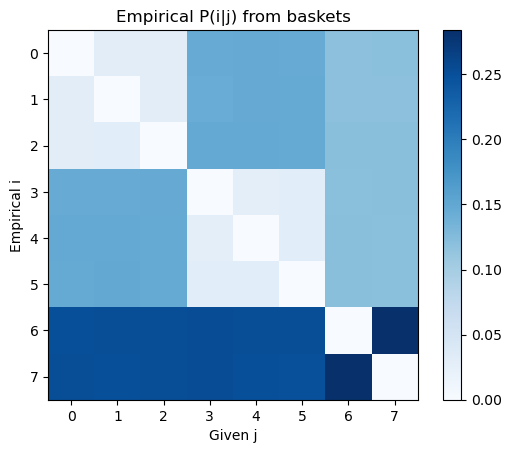

In [38]:
## baskets generation and distribution visualization

data_gen = SyntheticDataGenerator()
n_baskets = num_baskets
baskets = data_gen.generate_synthetic_dataset(n_baskets)
n_items = len(data_gen.assortment)


# Compute empirical P(i|j) from baskets
P_ij_true = np.zeros((n_items, n_items))
for basket in baskets:
    for i in basket:
        for j in basket:
            if i != j:
                P_ij_true[i, j] += 1

# Normalize: P(i|j) = count(i,j) / count(j)
P_ij_true_norm = P_ij_true / (np.sum(P_ij_true, axis=0, keepdims=True) + 1e-10)

plt.imshow(P_ij_true_norm, cmap='Blues')
plt.xlabel('Given j')
plt.ylabel('Empirical i')
plt.title('Empirical P(i|j) from baskets')
plt.colorbar()
plt.show()

In [39]:
# I will consider a set of baskets  and see how they are treated by the old model at each step
basket_batch = baskets[:basket_size]
# fit <- train_step <- basket_loss <- context_embedding

In [40]:
# (context, target_item) pairs creation and context embedding in the old model

print(f"Baskets:")
print(basket_batch, '\n')

batch_contexts = []
target_items_idx_for_mask = []
target_items = []

for basket in basket_batch:
    target_item_idx = random.randint(0, len(basket)-1)
    target_items_idx_for_mask.append(target_item_idx)
    target_item = basket[target_item_idx]
    context_items = [i for i in basket if i != target_item]
    batch_contexts.append(context_items)
    target_items.append(target_item)

print(f"Batch contexts:")
print(batch_contexts)
print(f"Target items indices:")
print(target_items_idx_for_mask) 
print(f"Target items:")
print(target_items, '\n')

# Context embedding : old model

def old_context_embed(context_items: list) -> tf.Tensor:
    """Returns the context embedding matrix. [self.embedding_dim]"""

    context_items = tf.convert_to_tensor(context_items, dtype=tf.int32)
    context_emb = tf.gather(Wi, context_items, axis=1)
    attn_logits = tf.tensordot(wa, context_emb, axes=1)
    attn_weights = tf.nn.softmax(attn_logits)
    context_vec = tf.reduce_sum(
        context_emb * tf.expand_dims(attn_weights, axis=0), axis=1
    )
    return context_vec

old_context_embeddings = np.array([old_context_embed(context).numpy().tolist() for context in batch_contexts])
print(f"Old context embeddings:")
print(old_context_embeddings)


Baskets:
[[0, 6], [1, 2, 3, 6], [3, 7]] 

Batch contexts:
[[0], [1, 3, 6], [3]]
Target items indices:
[1, 1, 1]
Target items:
[6, 2, 7] 

Old context embeddings:
[[ 0.014  0.048  0.185 -0.086 -0.012]
 [-0.009 -0.023  0.086  0.012  0.079]
 [-0.099 -0.045 -0.004 -0.08   0.008]]


In [42]:
# (context, target_item) pairs creation and context embedding in the new model

print(f"Baskets:")
basket_batch_ragged = tf.ragged.constant(basket_batch, dtype=tf.int32)
print(basket_batch_ragged, '\n')

new_target_items_idx_for_mask = tf.map_fn(
                lambda x: tf.random.uniform(shape=[], maxval=x.shape[0], dtype=tf.int32), 
                basket_batch_ragged, 
                fn_output_signature=tf.int32)

target_items = tf.map_fn(
                lambda args: args[0][args[1]],
                (basket_batch_ragged, new_target_items_idx_for_mask),
                fn_output_signature=tf.int32)

#print(f"Target items:")
#print(target_items.numpy())
#print(f"Target items indices in baskets:")
#print(new_target_items_idx_for_mask.numpy(), '\n')

print("Target items are: ")
target_items_idx_for_mask = tf.constant(target_items_idx_for_mask, dtype=tf.int32)
print(target_items.numpy())
print(f"Their target items indices in baskets:")
print(target_items_idx_for_mask.numpy(), '\n')
# batch contexts creation

mask = tf.map_fn(
                lambda x: tf.one_hot(x[0], depth=tf.cast(x[1], tf.int32), on_value=False, off_value=True, dtype=tf.bool),
                (target_items_idx_for_mask, basket_batch_ragged.row_lengths()),
                fn_output_signature=tf.RaggedTensorSpec(shape=[None], dtype=tf.bool)
            )
new_context_items = tf.ragged.boolean_mask(basket_batch_ragged, mask)

print(f"Contexts:")
print(new_context_items, '\n')

# Context embedding : new model

def new_context_embed(context_items: tf.Tensor) -> tf.Tensor:
    """Returns the context embedding matrix. [self.embedding_dim]"""

    context_emb = tf.gather(tf.transpose(Wi), context_items, axis=0)          
    attn_logits = tf.ragged.map_flat_values(
        lambda x: tf.tensordot(x, wa, axes=1), context_emb
    )
    attn_weights = tf.map_fn(
        lambda x: tf.nn.softmax(x), attn_logits
    )
    context_vec = tf.map_fn(
        lambda args: tf.reduce_sum(tf.transpose(args[0])*args[1] , axis=1),
        (context_emb, attn_weights), fn_output_signature=tf.float32
    )
    return context_vec

new_context_embeddings = new_context_embed(new_context_items)
print(f"Context embeddings:")
print(new_context_embeddings.numpy())

Baskets:
<tf.RaggedTensor [[0, 6], [1, 2, 3, 6], [3, 7]]> 

Target items are: 
[0 1 7]
Their target items indices in baskets:
[1 1 1] 

Contexts:
<tf.RaggedTensor [[0], [1, 3, 6], [3]]> 

Context embeddings:
[[ 0.014  0.048  0.185 -0.086 -0.012]
 [-0.009 -0.023  0.086  0.012  0.079]
 [-0.099 -0.045 -0.004 -0.08   0.008]]


In [29]:
## No problem to select target items and compute context embeddings in the old and new models

## Now we can compare the basket losses computation in the old and new models

In [30]:
# NLL loss

# Old model
def old_nll_loss(context_items: list, target_item: int) -> tf.Tensor:
    """Calculates the loss using a simple, naive softmax approach."""

    context_vec = old_context_embed(context_items)
    scores = tf.tensordot(Wo, context_vec, axes=1)
    return -tf.math.log(tf.nn.softmax(scores)[target_item])

old_model_nll_loss = []

for context, target_item in zip(batch_contexts, target_items):
    loss = old_nll_loss(context, target_item)
    old_model_nll_loss.append(loss.numpy().tolist())

print(f"Old model NLL loss:")
print(np.array(old_model_nll_loss), '\n')

# New model
def new_nll_loss(context_items: tf.Tensor, target_items: tf.Tensor) -> tf.Tensor:
        """Calculates the loss using a simple, naive softmax cross-entropy approach."""
        
        context_vec = new_context_embed(context_items)
        scores = tf.map_fn(
            lambda x: tf.tensordot(Wo, x, axes=1), context_vec
        )
        scores_softmax = tf.nn.softmax(scores)

        target_items_scores = tf.gather_nd(
            scores_softmax,
            tf.stack([tf.range(tf.shape(target_items)[0]), target_items], axis=1)
        )
        return -tf.math.log(target_items_scores)



new_model_nll_loss = new_nll_loss(new_context_items, target_items)
print(f"New model NLL loss:")
print(new_model_nll_loss.numpy())

Old model NLL loss:
[2.085 2.089 2.075 2.098 2.079 2.079 2.1   2.074 2.074 2.08 ] 

New model NLL loss:
[2.085 2.089 2.075 2.098 2.079 2.079 2.1   2.074 2.074 2.08 ]


In [34]:
# NCE Loss


# Old model

def old_score(context_vec: tf.Tensor, item: int) -> tf.Tensor:
        """Returns the score of the item given the context vector."""

        return tf.tensordot(Wo[item], context_vec, axes=1)

def old_nce_loss(context_items: list, target_item: int) -> tf.Tensor:
    """Calculates the loss using Noise Contrastive Estimation (NCE)."""

    context_vec = old_context_embed(context_items)
    pos_score = old_score(context_vec, target_item)
    
    # Negative sampling: exclude basket items
    neg_items = []
    force_ending_cpt = 0
    while len(neg_items) < K_noise and force_ending_cpt < 1000:
         force_ending_cpt += 1
         candidate_item = random.randint(0, n_items - 1)
         if candidate_item not in context_items and candidate_item != target_item:
            neg_items.append(candidate_item)

    # NCE probabilities

    P_1 = 1 / (1 + K_noise * Q_distribution[target_item]*tf.exp(-pos_score))
    loss = -tf.math.log(P_1)

    
    for i in neg_items:
        neg_score = old_score(context_vec, i)
        KQ_neg = K_noise * Q_distribution[i]
        P_0 = 1 - (1 / (1 + KQ_neg*tf.exp(-neg_score)))
        loss -= tf.math.log(P_0)
    return loss

old_model_nce_loss = []
for context, target_item in zip(batch_contexts, target_items):
    loss = old_nce_loss(context, target_item)
    old_model_nce_loss.append(loss.numpy().tolist())

np.set_printoptions(precision=3)
print("Batch contexts - target items scores in the old model:")
print(np.array([old_score(old_context_embed(context), target_item).numpy().tolist() for context, target_item in zip(batch_contexts, target_items)]))

print(f"Old model NCE loss:")
print(np.array(old_model_nce_loss), '\n')



# New model

def new_score(context_vec: tf.Tensor, items: tf.Tensor) -> tf.Tensor:
    """Returns the score of the item given the context vector."""

    return tf.map_fn(
         lambda args: tf.tensordot(Wo[args[1].numpy()], args[0], axes=1),
         (context_vec, items), fn_output_signature=tf.float32)

def new_nce_loss(context_items: tf.Tensor, target_items: tf.Tensor) -> tf.Tensor:
    """Calculates the loss using Noise Contrastive Estimation (NCE)."""

    context_vec = new_context_embed(context_items)
    pos_score = new_score(context_vec, target_items)
    batch_size = tf.shape(target_items)[0]
    list_neg_items = []

    for i in range(batch_size):
        neg_items = []
        force_ending_cpt = 0
        while len(neg_items) < K_noise and force_ending_cpt < 1000:
            force_ending_cpt += 1
            candidate_item = random.randint(0, n_items - 1)
            if candidate_item not in context_items[i]and candidate_item != target_items[i]:
                neg_items.append(candidate_item)
        list_neg_items.append(neg_items)

    

    P_1 = tf.map_fn(
        lambda args: 1 / (1 + K_noise * Q_distribution[args[1]]*tf.exp(-args[0])),
        (pos_score, target_items), fn_output_signature=tf.float32)
    loss = -tf.math.log(P_1)

    for i in range(len(neg_items)):
        neg_score = new_score(context_vec, tf.gather(list_neg_items, i, axis=1))
        P_0 = tf.map_fn(
        lambda args: 1- (1 / (1 + K_noise * Q_distribution[args[1]]*tf.exp(-args[0]))),
        (neg_score, target_items), fn_output_signature=tf.float32)
        loss -= tf.math.log(P_0)
    
    return loss


print("Batch contexts - target items scores in the new model:")
print(new_score(new_context_embeddings, target_items))

print(f"New model NCE loss:")
print(new_nce_loss(new_context_items, target_items), '\n')


Batch contexts - target items scores in the old model:
[-0.008 -0.004 -0.002 -0.011  0.     0.    -0.024  0.003  0.003 -0.001]
Old model NCE loss:
[3.242 3.273 3.233 3.339 3.259 3.259 3.287 3.269 3.248 3.262] 

Batch contexts - target items scores in the new model:
tf.Tensor([-0.008 -0.004 -0.002 -0.011  0.     0.    -0.024  0.003  0.003 -0.001], shape=(10,), dtype=float32)
New model NCE loss:
tf.Tensor([3.248 3.278 3.26  3.3   3.259 3.259 3.27  3.272 3.272 3.272], shape=(10,), dtype=float32) 



In [32]:
# Test of get_batches

def get_batches(dataset: tf.Tensor) -> list:
    """Generates batches of baskets for training or testing."""

    indices = list(range(dataset.shape[0]))
    random.shuffle(indices)
    for i in range(0, len(indices), batch_size):
        batch_indices = indices[i : i + batch_size]
        yield tf.gather(dataset, batch_indices)

for batch in get_batches(basket_batch_ragged):
    print(batch.numpy())
    print("Yaaaay")  # Just to show the first batch


[array([0, 1, 7], dtype=int32) array([7], dtype=int32)
 array([5, 6, 7], dtype=int32) array([6], dtype=int32)
 array([2, 5, 6], dtype=int32) array([1, 5, 7], dtype=int32)
 array([1, 2, 3, 6], dtype=int32) array([0, 5, 6], dtype=int32)
 array([3, 7], dtype=int32) array([0, 6], dtype=int32)]
Yaaaay


In [46]:
import tensorflow as tf
@tf.function
def context_embed(context_items: tf.Tensor) -> tf.Tensor:
    """Returns the context embedding matrix. [self.embedding_dim]"""


    context_emb = tf.gather(Wi, context_items, axis=0)  
    attn_logits = tf.ragged.map_flat_values(
        lambda x: tf.tensordot(x, wa, axes=1), context_emb
    )
    attn_weights = tf.map_fn(
        lambda x: tf.nn.softmax(x), attn_logits
    )
    context_vec = tf.map_fn(
        lambda args: tf.reduce_sum(tf.transpose(args[0])*args[1] , axis=1),
        (context_emb, attn_weights), fn_output_signature=tf.float32
    )
    return context_vec

In [ ]:
context_items = tf.ragged.constant([[0, 1, 2], [3, 4]], dtype=tf.int32)
context_embeddings = context_embed(context_items)
print("Context embeddings:")
print(context_embeddings.numpy())

W0000 00:00:1752672677.165023 8401027 op_level_cost_estimator.cc:699] Error in PredictCost() for the op: op: "Softmax" attr { key: "T" value { type: DT_FLOAT } } inputs { dtype: DT_FLOAT shape { unknown_rank: true } } device { type: "CPU" model: "0" frequency: 2400 num_cores: 8 environment { key: "cpu_instruction_set" value: "ARM NEON" } environment { key: "eigen" value: "3.4.90" } l1_cache_size: 16384 l2_cache_size: 524288 l3_cache_size: 524288 memory_size: 268435456 } outputs { dtype: DT_FLOAT shape { unknown_rank: true } }
2025-07-16 15:31:17.216945: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: INVALID_ARGUMENT: indices[5] = 5 is not in [0, 5)
	 [[{{node RaggedGather/GatherV2}}]]


InvalidArgumentError: Graph execution error:

Detected at node RaggedGather/GatherV2 defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/Users/souleiman.sbai/conda/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/Users/souleiman.sbai/conda/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/Users/souleiman.sbai/conda/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start

  File "/Users/souleiman.sbai/conda/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 211, in start

  File "/Users/souleiman.sbai/conda/lib/python3.12/asyncio/base_events.py", line 645, in run_forever

  File "/Users/souleiman.sbai/conda/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once

  File "/Users/souleiman.sbai/conda/lib/python3.12/asyncio/events.py", line 88, in _run

  File "/Users